In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

Original data set:
https://www.kaggle.com/datasets/rohitgrewal/hr-data-mnc

Due to the large scale of the original dataset (2 million records), a subset of 100,000 records was retained for the analysis to optimize computational efficiency while maintaining statistical significance.

In [163]:
df= pd.read_csv("Raw_HR_Data_MNC.xlsx")

Show 5 datas

In [164]:
df.head(5)

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082


Data Understanding & Quality Assessment

In [165]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   Unnamed: 0          100000 non-null  int64
 1   Employee_ID         100000 non-null  str  
 2   Full_Name           100000 non-null  str  
 3   Department          100000 non-null  str  
 4   Job_Title           100000 non-null  str  
 5   Hire_Date           100000 non-null  str  
 6   Location            100000 non-null  str  
 7   Performance_Rating  100000 non-null  int64
 8   Experience_Years    100000 non-null  int64
 9   Status              100000 non-null  str  
 10  Work_Mode           100000 non-null  str  
 11  Salary_INR          100000 non-null  int64
dtypes: int64(4), str(8)
memory usage: 9.2 MB


In [166]:
df.describe()

,Unnamed: 0,Performance_Rating,Experience_Years,Salary_INR
count,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,49999.500000,3.002780,5.024800,8.960663e+05
std,28867.657797,1.414932,3.614664,4.020098e+05
min,0.000000,1.000000,0.000000,3.002550e+05
25%,24999.750000,2.000000,2.000000,6.157448e+05
50%,49999.500000,3.000000,5.000000,8.105475e+05
75%,74999.250000,4.000000,8.000000,1.073683e+06
max,99999.000000,5.000000,15.000000,2.997010e+06


Data Checking & Cleaning

Technical checks confirm zero missing values and zero duplicates.

In [157]:
#Checking Null Value
print(df.isnull().sum())

Unnamed: 0            0
Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
dtype: int64


In [167]:
pd.DataFrame({
    "missing":df.isnull().sum(),
    "percentage":df.isnull().sum()*100/len(df)
})

,missing,percentage
Unnamed: 0,0,0.0
Employee_ID,0,0.0
Full_Name,0,0.0
Department,0,0.0
Job_Title,0,0.0
Hire_Date,0,0.0
Location,0,0.0
Performance_Rating,0,0.0
Experience_Years,0,0.0
Status,0,0.0


In [168]:
#Check duplicated value
df.duplicated().sum()

np.int64(0)

In [171]:
df.drop_duplicates()

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Tenure_Years,Experience_Level
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,15,Senior
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,8,Mid
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,3,Junior
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,3,Junior
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,EMP0099996,John Miller,IT,Software Engineer,2025-08-08,"Masonmouth, Norway",1,0,Resigned,On-site,881818,1,NaN
99996,99996,EMP0099997,Kara Adams,Marketing,Content Strategist,2022-02-04,"Romeroshire, Azerbaijan",2,3,Active,On-site,751300,4,Junior
99997,99997,EMP0099998,Misty Jones,Marketing,SEO Specialist,2024-07-02,"Cooperfurt, India",3,1,Retired,On-site,627186,2,Junior
99998,99998,EMP0099999,Matthew Wilson,IT,Software Engineer,2021-03-11,"Josephchester, Cayman Islands",4,4,Resigned,On-site,632359,5,Junior


Data Transforming

Hire_Date was converted to a datetime object to enable time-based calculations.

In [172]:
#Data Transformation: Date Conversion
# Converting string date to datetime objects for calculation
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])


current_year = 2026
df['Tenure_Years'] = current_year - df['Hire_Date'].dt.year

# Creating 'Experience_Level' to group employees into categories
bins = [0, 5, 10, 50]
labels = ['Junior', 'Mid', 'Senior']
df['Experience_Level'] = pd.cut(df['Experience_Years'], bins=bins, labels=labels)

#Standardizing Categorical Data
# Ensuring consistent naming conventions for departmental analysis
df['Department'] = df['Department'].str.strip()


display(df.head())

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Tenure_Years,Experience_Level
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,15,Senior
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,8,Mid
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,3,Junior
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,3,Junior
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082,2,NaN


A Tenure_Years column was created to measure loyalty, and Experience_Level bins (Junior, Mid, Senior) were established to allow for group-based comparisons during EDA

Exploratory Data Analysis

Transform & mean,median,standard deviation

In [ ]:
df['Hire_Date'] = pd.to_datetime(df['Hire_Date'])
df['Tenure_Years'] = 2026 - df['Hire_Date'].dt.year

# Calculating Mean, Median, Min, Max, and Variability
print("--- Descriptive Statistics for Key HR Metrics ---")
stats_summary = df[['Experience_Years', 'Salary_INR', 'Performance_Rating', 'Tenure_Years']].describe()
print(stats_summary)

# Explicitly showing Variability (Standard Deviation)
print("\n--- Variability (Standard Deviation) ---")
print(df[['Experience_Years', 'Salary_INR', 'Performance_Rating', 'Tenure_Years']].std())

--- Descriptive Statistics for Key HR Metrics ---
       Experience_Years    Salary_INR  Performance_Rating   Tenure_Years
count     100000.000000  1.000000e+05       100000.000000  100000.000000
mean           5.024800  8.960663e+05            3.002780       6.403900
std            3.614664  4.020098e+05            1.414932       3.642331
min            0.000000  3.002550e+05            1.000000       1.000000
25%            2.000000  6.157448e+05            2.000000       3.000000
50%            5.000000  8.105475e+05            3.000000       6.000000
75%            8.000000  1.073683e+06            4.000000       9.000000
max           15.000000  2.997010e+06            5.000000      16.000000

--- Variability (Standard Deviation) ---
Experience_Years           3.614664
Salary_INR            402009.826363
Performance_Rating         1.414932
Tenure_Years               3.642331
dtype: float64


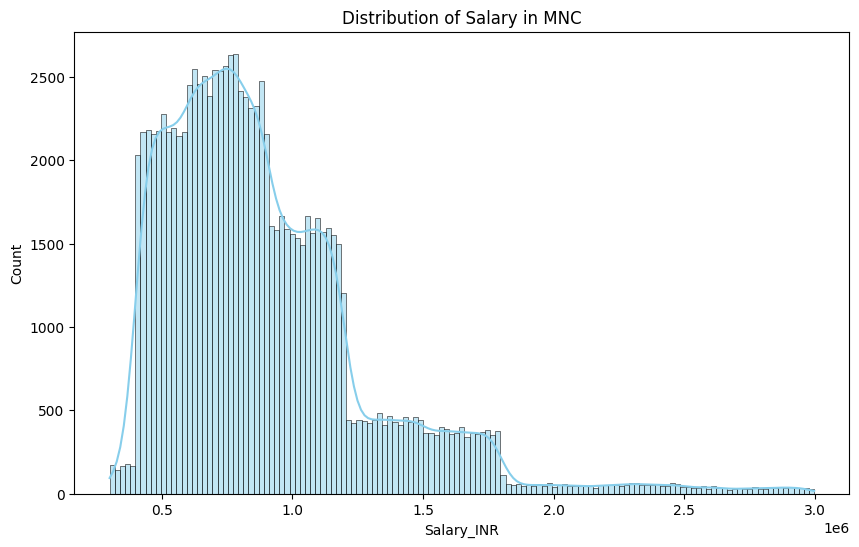

C:\Users\USER\AppData\Local\Temp\ipykernel_8100\3198385374.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department', y='Salary_INR', data=df, palette='Set2')


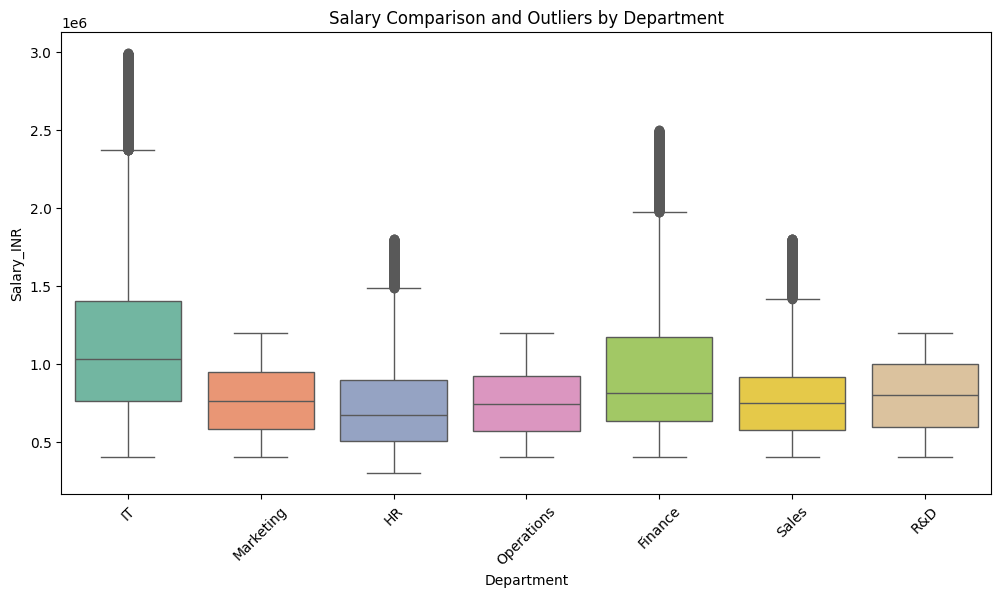

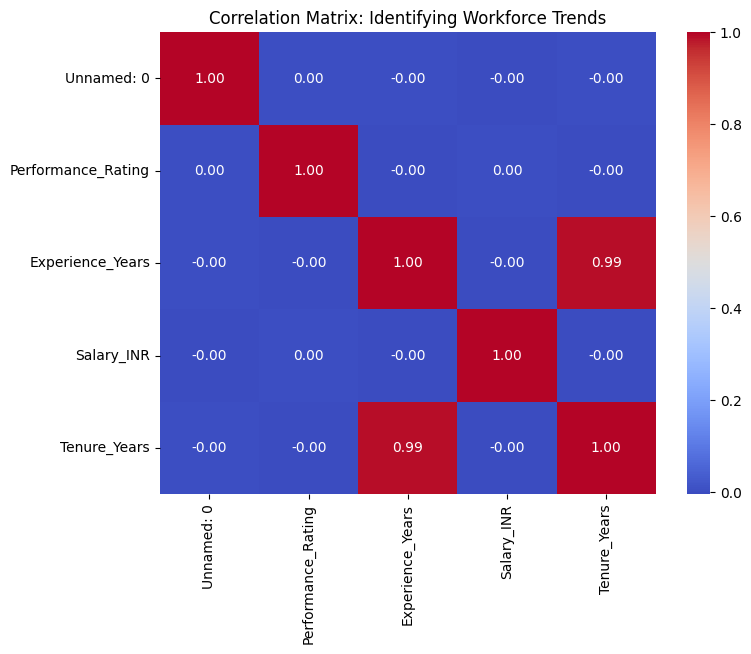

In [174]:

# Data Visualization: Distributions
# Using a Histogram to explore the distribution of Experience
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary_INR'], kde=True, color='skyblue')
plt.title('Distribution of Salary in MNC')
plt.show()


# Data Visualization: Comparisons
# Using a Boxplot to compare Salary distribution by Department and identify outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x='Department', y='Salary_INR', data=df, palette='Set2')
plt.title('Salary Comparison and Outliers by Department')
plt.xticks(rotation=45)
plt.show()

# Identifying Relationships and Trends
# Using a Heatmap to identify correlations between numerical variables
plt.figure(figsize=(8, 6))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Identifying Workforce Trends')
plt.show()

Observation: Experience Distribution (Histogram)
- The histogram reveals that the majority of employees fall within the mid-career range, indicating a stable and experienced workforce.

Observation: Salary Comparisons (Boxplot)
- The boxplot identifies specific departments with higher salary variability and highlights "outliers"—employees whose compensation is significantly higher than the median for their role.

Observation: Relationships (Heatmap)
- The correlation matrix shows a strong positive relationship between Experience_Years and Salary_INR, confirming that seniority is the primary driver for salary increases in this MNC.

Export Cleaned Data

In [ ]:
df.to_csv('Cleaned_HR_Data_MNC.xlsx', index=False)

Drop unrelated column

In [175]:
df = df.drop(columns=['Unnamed: 0', 'Employee_ID', 'Full_Name', 'Job_Title', 'Hire_Date', 'Location'])

# Verify the column is gone
print(df.columns)

Index(['Department', 'Performance_Rating', 'Experience_Years', 'Status',
       'Work_Mode', 'Salary_INR', 'Tenure_Years', 'Experience_Level'],
      dtype='str')


In [176]:
numerical_cols=df.select_dtypes(include=["int64","float64"]).columns
categorical_cols=df.select_dtypes(exclude=["int64","float64"]).columns

print(numerical_cols)
print(categorical_cols)

Index(['Performance_Rating', 'Experience_Years', 'Salary_INR'], dtype='str')
Index(['Department', 'Status', 'Work_Mode', 'Tenure_Years',
       'Experience_Level'],
      dtype='str')


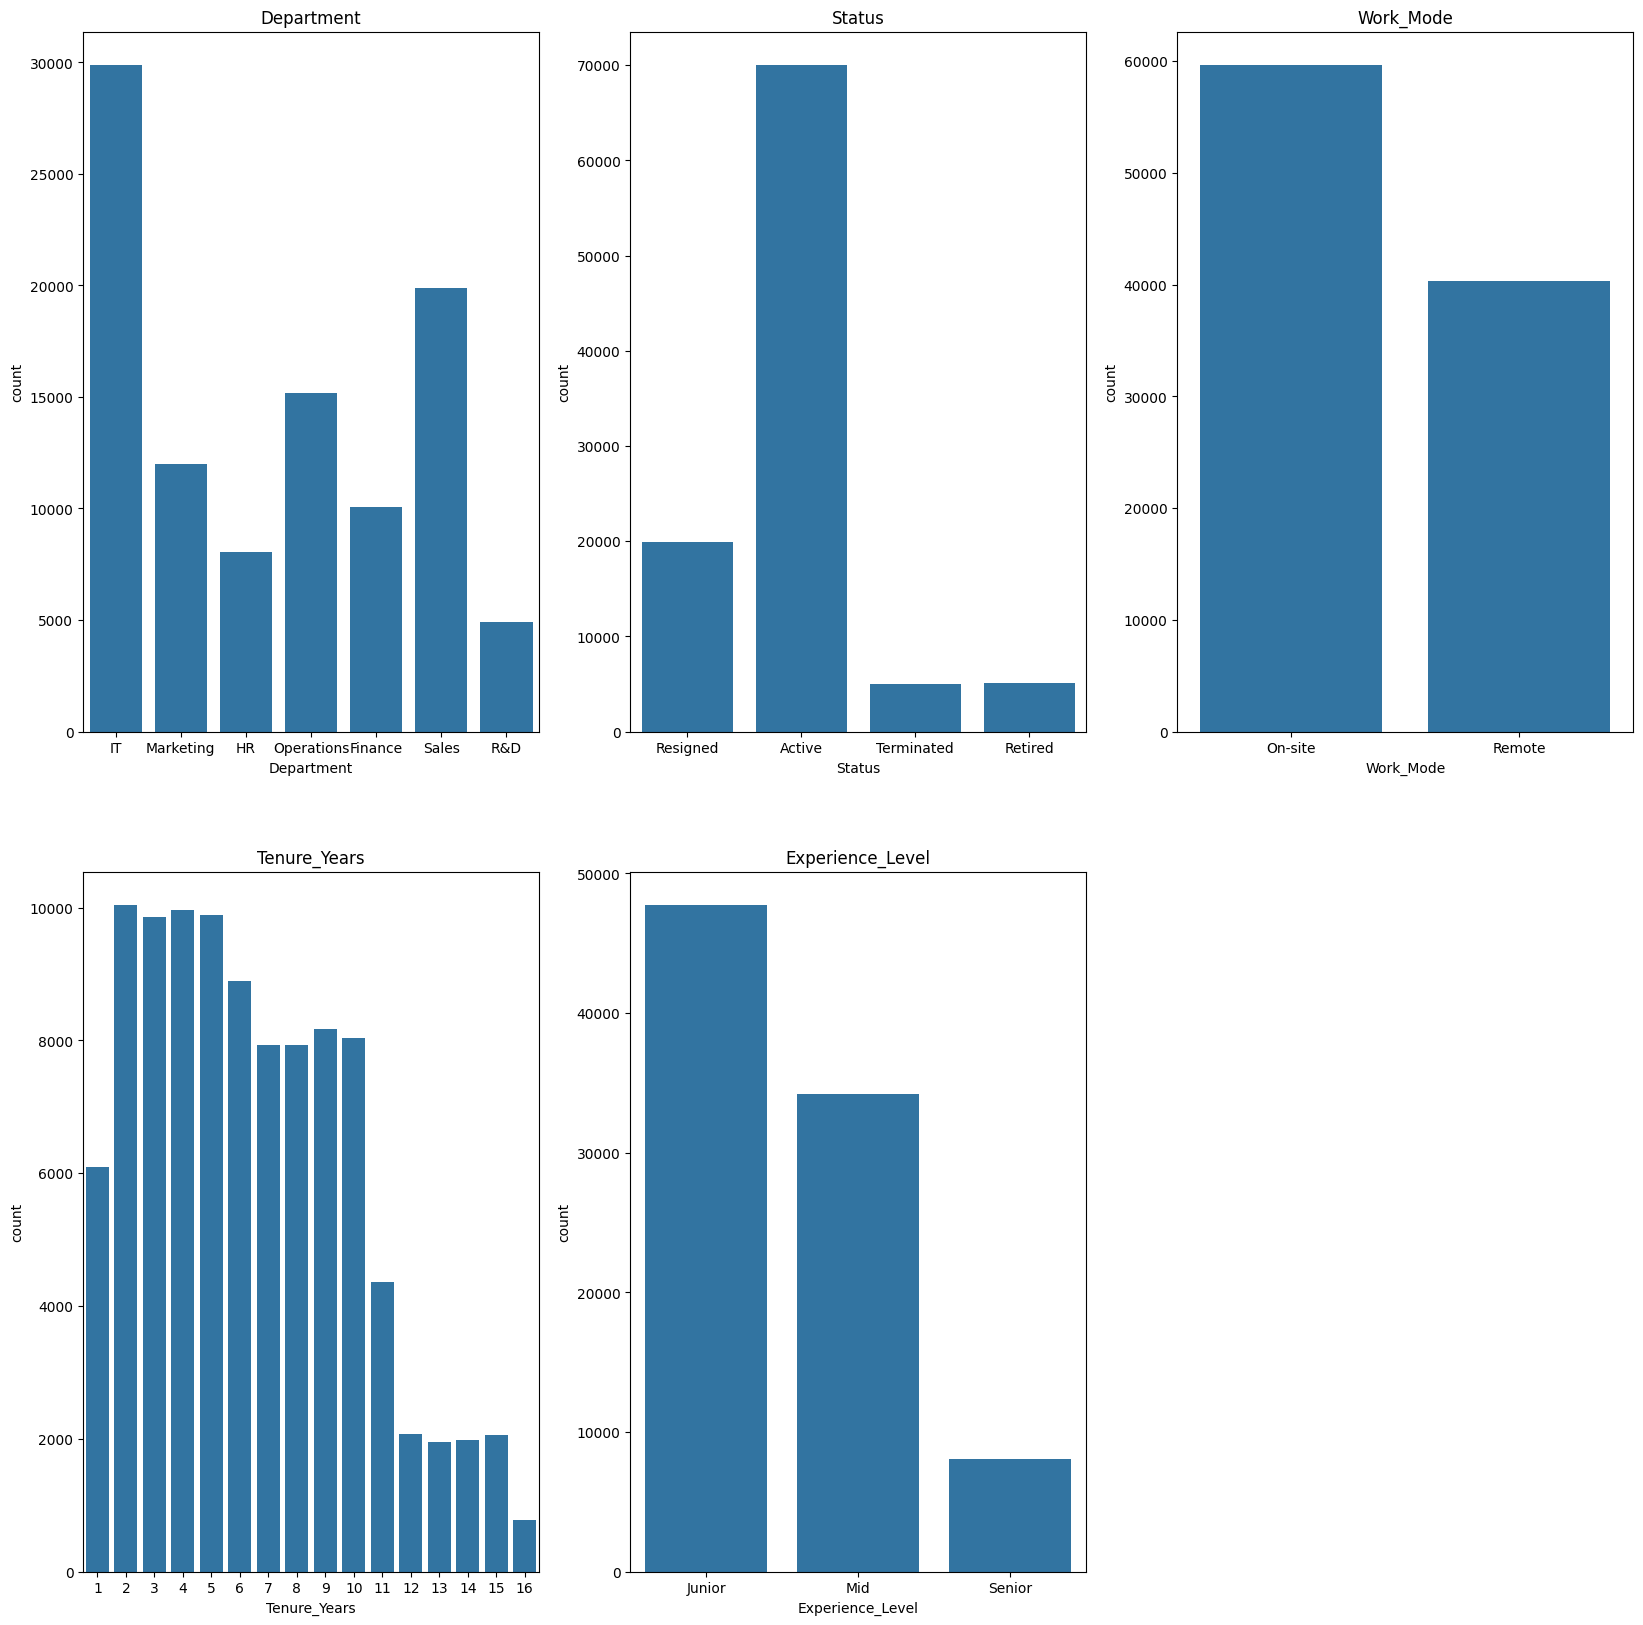

In [177]:
# Bar

def univariate_categorical(df, categorical_features):
    # Setup canvas untuk gambar-gambar chart
    n_columns = 3
    n_rows = -(-len(categorical_cols) // n_columns)

    plt.figure(figsize=(20, 20))

    for i,col in enumerate(categorical_features):
        plt.subplot(n_rows, n_columns, i+1)
        sns.countplot(x=col, data=df)
        plt.title(col)

    plt.show()


univariate_categorical(df, categorical_cols)


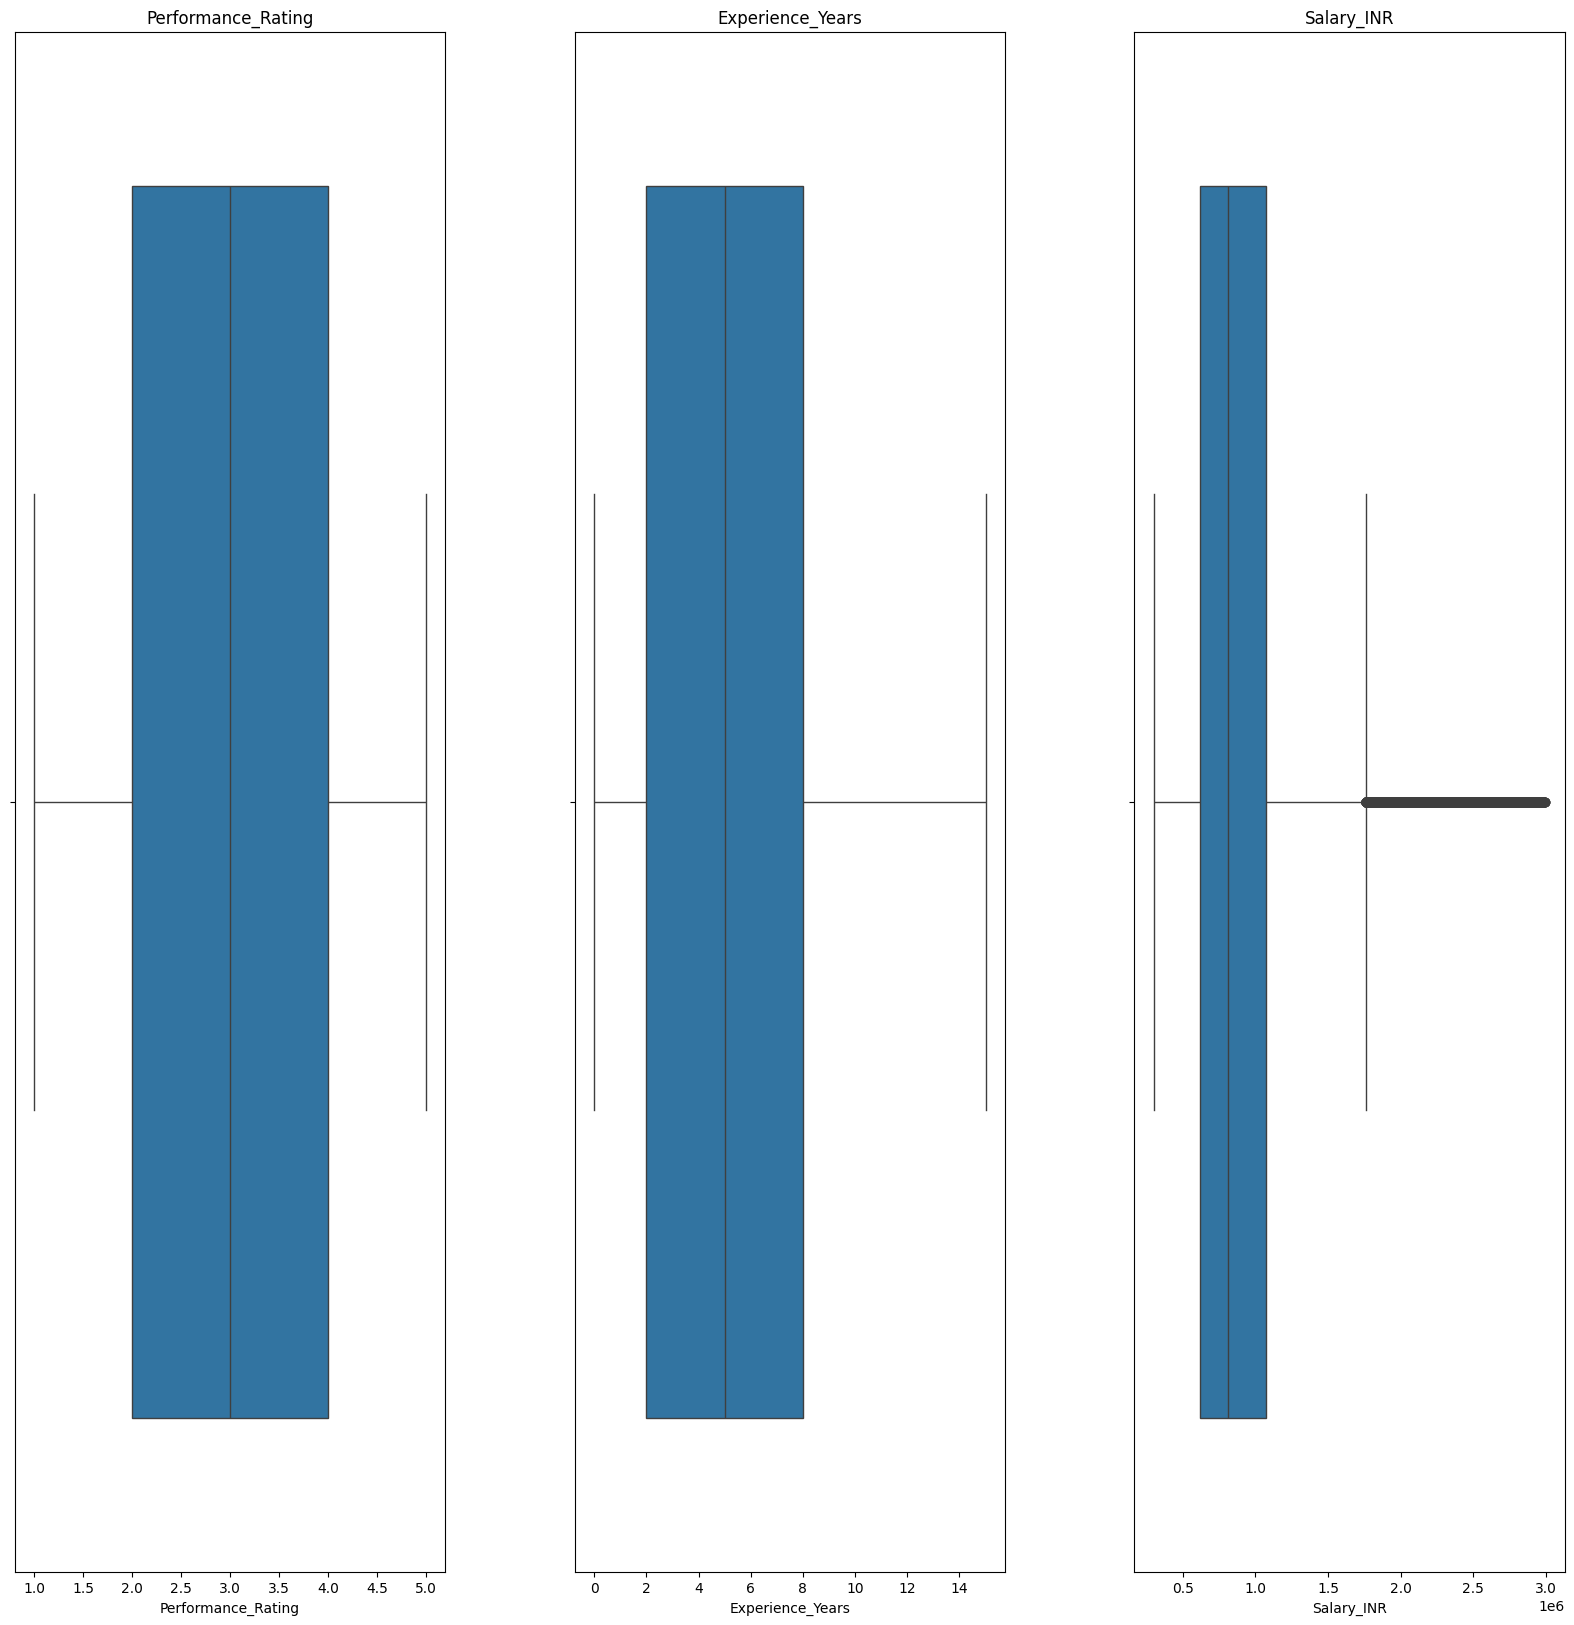

In [ ]:
# histogram/boxplot

def univariate_numerical(df, numerical_features):
    # Setup canvas untuk gambar-gambar chart
    n_columns = 3
    n_rows = -(-len(numerical_cols) // n_columns)

    plt.figure(figsize=(20, 20))

    for i,col in enumerate(numerical_features):
        plt.subplot(n_rows, n_columns, i+1)
        # sns.histplot(x=col, data=df)

        sns.boxplot(x=col, data=df)
        plt.title(col)
    plt.subplots_adjust(hspace=0.5, wspace=0.3) 
    plt.show()


univariate_numerical(df, numerical_cols)
